### Selecting Physical System and Run with Classical ODE Solve Method (20 pts)

Problem: Damped harmonic oscillator

Equation of motion is given by

$$
\begin{gather*}
m\ddot{x}=-kx-b\dot{x}\\
\ddot{x}+2\gamma\dot{x}+\omega^2x=0
\end{gather*}
$$
with $\omega_0^2=k/m$ and $\gamma=b/(2m)$. We can solve this problem using ansatz: $x(t)=e^{\lambda t}$. Therefore,
$$
\begin{align*}
(\lambda^2+2\gamma\lambda+\omega_0^2)x=0
\end{align*}
$$
The non trivial solution is given as
$$
\begin{gather*}
\lambda=-\gamma\pm\sqrt{\gamma^2-\omega_0^2}\\
\therefore x(t)=Ae^{(-\gamma+\sqrt{\gamma^2-\omega_0^2})t} + Be^{(-\gamma-\sqrt{\gamma^2-\omega_0^2})t}
\end{gather*}
$$
In this note, we treat only underdamped case, $\gamma^2<\omega_0^2$. Defining $\omega=\sqrt{\omega_0^2-\gamma^2}$, we have the general solution as
$$
\begin{align*}
x(t)=Ae^{(-\gamma+i\omega)t} + Be^{(-\gamma-i\omega)t}=e^{-\gamma t}(Ae^{i\omega t}+Be^{-i\omega t})=Ce^{-\gamma t}\cos(\omega t+\phi)
\end{align*}
$$
Here, $C$ and $\phi$ will be determined by initial conditions.

In [93]:
import numpy as np
import matplotlib.pyplot as plt


h = 0.01 # Time step
t = np.arange(0, 40+h, h) # Time
r = np.zeros((2, t.size), dtype=float)
# r[0] = x, position
# r[1] = v, velocity

# INITIAL CONDITIONS
r[0, 0] = 2.0 # Initial condition of x
r[1, 0] = 1.0 # Initial condition of v
w0 = 1.0 # \omega_0
g = 0.1 # \gamma
w = np.sqrt(w0**2 - g**2) # \omega=\sqrt{\omega_0^2-\gamma^2}

# ODE FUNCTION

def f(r, t, w0, g):
    r_new = np.zeros((r.shape[0]), dtype=float)
    r_new[0] = r[1]
    r_new[1] = -w0*r[0] - 2*g*r[1]

    return r_new

In [94]:
# SELECTED CLASSICAL METHOD FOR SOLVING ODE: RK4

def RK4(f, r, t, h, w0=w0, g=g):
    k1 = h*f(r, t, w0, g)
    k2 = h*f(r + 0.5*k1, t + 0.5*h, w0, g)
    k3 = h*f(r + 0.5*k2, t + 0.5*h, w0, g)
    k4 = h*f(r + k3, t + h, w0, g)

    return r + (k1 + 2*k2 + 2*k3 + k4)/6.0

In [95]:
# SOLVE ODE

for i, t_i in enumerate(range(t.size - 1)):
    r[:, i+1] = RK4(f, r[:, i], t_i, h)

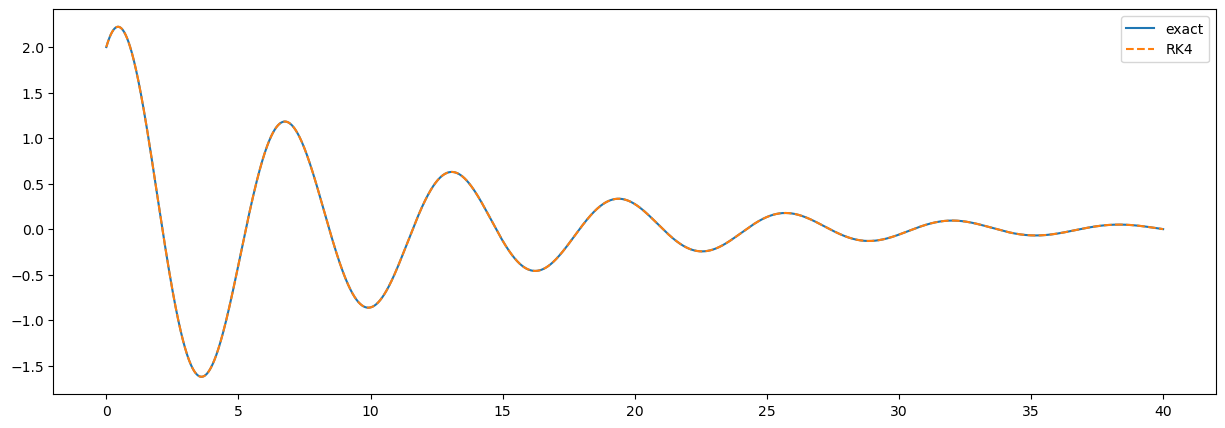

In [106]:
# VISUALIZATION
phi = np.arctan(-(g+r[1,0]/r[0,0])/w)
x_exact = r[0,0]/np.cos(phi)*np.exp(-g*t)*np.cos(w*t + phi) # Exact solution

plt.figure(figsize=(15, 5))
plt.plot(t, x_exact, label="exact")
plt.plot(t, r[0], '--', label="RK4")

plt.legend()
plt.show()


### Run with Simple NN (20pts)

In [ ]:
import torch
import torch.nn as nn

# SELECTED NEURAL NETWORK FOR SOLVING ODE

# YOUR DESINGED NEURAL NETWORK CODE HERE (e.g SimpleNN())

In [ ]:
# DEFINE RESIDUAL FUNCTION

# YOUR RESIDUAL FUNCTION CODE HERE 

In [ ]:
# DATASET GENERATION

# YOUR DATASET GENERATION CODE HERE

In [ ]:
# TRAINING NEURAL NETWORK

# YOUR TRAINING CODE HERE

### Analysis Classical Method and Deep Learning Based Method (30pts)

YOUR SELECTED ANALYSIS METHOD (OR ANALYSIS PARAMETERS) EXPLANATION HERE (in markdown)

In [ ]:
# ANALYSIS

# YOUR ANALYSIS CODE HERE

In [ ]:
# VISUALIZATION

# YOUR VISUALIZATION FOR ANALYSIS CODE HERE

### Discuss the results (30pts)

DISCUSSING THE ANALYSIS RESULTS (in 200 words)